# Аппроксимация функции

Функция (3): $u(x, y) = \sin(k_x x)\cos(k_y y)\exp(-\alpha (x^2 + y^2))$, $k_x = k_y = 3$, $\alpha = 0.3$, область $[-1, 1]^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata

## Данные

In [2]:
kx, ky, alpha = 3.0, 3.0, 0.3

In [3]:
R=1
L=1
def function(x, y):
    return np.sin(kx*x)*np.cos(ky*y)*np.exp(-alpha*(x**2 + y**2))

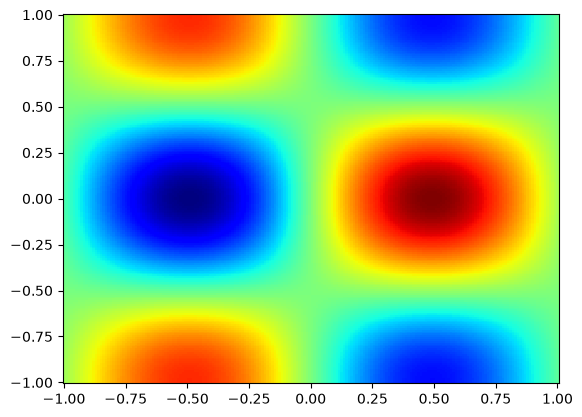

In [4]:
x=np.linspace(-R, R, 200)
y=np.linspace(-L, L, 200)
X, Y = np.meshgrid(x, y)
U = function(X, Y)
plt.pcolormesh(X, Y, U, shading="auto", cmap="jet")

In [5]:
rng = np.random.default_rng(0)
n_points = 4000
x_rand = rng.uniform(-R, R, n_points)
y_rand = rng.uniform(-L, L, n_points)
u_rand = function(x_rand, y_rand)

xy_train = torch.tensor(np.column_stack([x_rand, y_rand]), dtype=torch.float32)
u_train = torch.tensor(u_rand[:, None], dtype=torch.float32)

print("xy_train:", tuple(xy_train.shape), " u_train:", tuple(u_train.shape))
print("u min/max: %.3f / %.3f" % (u_rand.min(), u_rand.max()))

xy_train: (4000, 2)  u_train: (4000, 1)
u min/max: -0.925 / 0.924


## Модель

u уже лежит в [-1, 1], нормализация не нужна. 4 скрытых слоя по 20 нейронов, tanh (5 нейронов для этой функции не хватает).

In [6]:
class PINNModel(nn.Module):
    def __init__(self, input_size=2, nnodes=20, output_size=1, nhlayers=4, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(input_size, nnodes), activation()]
        for _ in range(nhlayers - 1):
            layers += [nn.Linear(nnodes, nnodes), activation()]
        layers.append(nn.Linear(nnodes, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, xy):
        return self.net(xy)


def make_model(seed=0):
    torch.manual_seed(seed)
    return PINNModel()


print(make_model())

PINNModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=1, bias=True)
  )
)


## Обучение

In [7]:
class TrainParams:
    def __init__(self, numEpoch, xy, u):
        self.numEpoch = numEpoch
        self.xy = xy
        self.u = u


def copyLoss(model, trp):
    return torch.mean((model(trp.xy) - trp.u) ** 2)


def train(model, opt, trp, scheduler=None, desc="Training"):
    hist_loss, hist_lr = [], []
    pbar = tqdm.tqdm(range(trp.numEpoch), desc=desc)
    for step in pbar:
        def closure():
            opt.zero_grad()
            loss = copyLoss(model, trp)
            loss.backward()
            return loss

        current_loss = opt.step(closure).item()
        hist_loss.append(current_loss)
        hist_lr.append(opt.param_groups[0]["lr"])
        if scheduler is not None:
            scheduler.step()
        if step % 50 == 0:
            pbar.set_description("%s | Step: %d | Loss: %.3e" % (desc, step, current_loss))
    return hist_loss, hist_lr

## Сравнение оптимизаторов

Adam, RMSprop, SGD по 3000 эпох, L-BFGS 150 шагов (у него внутри до 20 итераций на шаг).

In [8]:
torch.set_num_threads(4)
N_EPOCH = 3000

configs = {
    "Adam (lr=1e-2)":    (lambda p: torch.optim.Adam(p, lr=1e-2), N_EPOCH),
    "RMSprop (lr=1e-3)": (lambda p: torch.optim.RMSprop(p, lr=1e-3), N_EPOCH),
    "L-BFGS":            (lambda p: torch.optim.LBFGS(p, lr=1.0, max_iter=20, history_size=50,
                                                      line_search_fn="strong_wolfe"), 150),
    "SGD (momentum=0.9)": (lambda p: torch.optim.SGD(p, lr=1e-1, momentum=0.9), N_EPOCH),
}

models, histories, times = {}, {}, {}
for name, (make_opt, n_epoch) in configs.items():
    model = make_model(seed=0)
    opt = make_opt(model.parameters())
    t0 = time.time()
    hist, _ = train(model, opt, TrainParams(n_epoch, xy_train, u_train), desc=name)
    times[name] = time.time() - t0
    models[name], histories[name] = model, hist

Adam (lr=1e-2):   0%|          | 0/3000 [00:00<?, ?it/s]

Adam (lr=1e-2) | Step: 0 | Loss: 2.184e-01:   0%|          | 0/3000 [00:00<?, ?it/s]

Adam (lr=1e-2) | Step: 0 | Loss: 2.184e-01:   1%|▏         | 44/3000 [00:00<00:06, 437.40it/s]

Adam (lr=1e-2) | Step: 50 | Loss: 2.441e-02:   1%|▏         | 44/3000 [00:00<00:06, 437.40it/s]

Adam (lr=1e-2) | Step: 100 | Loss: 5.544e-03:   1%|▏         | 44/3000 [00:00<00:06, 437.40it/s]

...

SGD (momentum=0.9) | Step: 2900 | Loss: 1.190e-03:  94%|█████████▍| 2830/3000 [00:04<00:00, 700.75it/s]

SGD (momentum=0.9) | Step: 2900 | Loss: 1.190e-03:  97%|█████████▋| 2901/3000 [00:04<00:00, 701.23it/s]

SGD (momentum=0.9) | Step: 2950 | Loss: 1.528e-03:  97%|█████████▋| 2901/3000 [00:04<00:00, 701.23it/s]

SGD (momentum=0.9) | Step: 2950 | Loss: 1.528e-03:  99%|█████████▉| 2972/3000 [00:04<00:00, 702.12it/s]

SGD (momentum=0.9) | Step: 2950 | Loss: 1.528e-03: 100%|██████████| 3000/3000 [00:04<00:00, 698.66it/s]

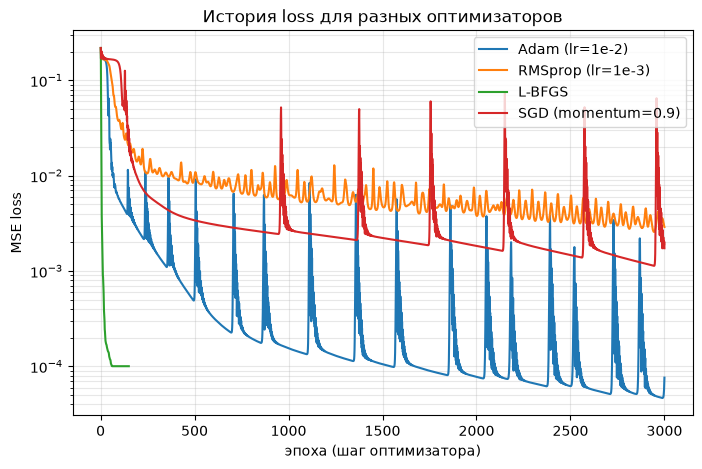

оптимизатор            final loss время, с
Adam (lr=1e-2)          7.611e-05      4.8
RMSprop (lr=1e-3)       2.895e-03      4.5
L-BFGS                  1.004e-04      2.7
SGD (momentum=0.9)      1.734e-03      4.3


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, hist in histories.items():
    ax.semilogy(np.arange(1, len(hist) + 1), hist, lw=1.5, label=name)
ax.set_xlabel("эпоха (шаг оптимизатора)")
ax.set_ylabel("MSE loss")
ax.set_title("История loss для разных оптимизаторов")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

print("%-20s %12s %8s" % ("оптимизатор", "final loss", "время, с"))
for name, hist in histories.items():
    print("%-20s %12.3e %8.1f" % (name, hist[-1], times[name]))

## SGD + LambdaLR

lr = 0.1 * 0.9995^epoch. При lr0 >= 0.2 SGD расходится (nan).

SGD + LambdaLR:   0%|          | 0/3000 [00:00<?, ?it/s]

SGD + LambdaLR | Step: 0 | Loss: 2.184e-01:   0%|          | 0/3000 [00:00<?, ?it/s]

SGD + LambdaLR | Step: 50 | Loss: 1.663e-01:   0%|          | 0/3000 [00:00<?, ?it/s]

SGD + LambdaLR | Step: 50 | Loss: 1.663e-01:   2%|▏         | 68/3000 [00:00<00:04, 672.32it/s]

SGD + LambdaLR | Step: 100 | Loss: 1.453e-01:   2%|▏         | 68/3000 [00:00<00:04, 672.32it/s]

...

SGD + LambdaLR | Step: 2850 | Loss: 1.039e-03:  96%|█████████▌| 2875/3000 [00:04<00:00, 695.64it/s]

SGD + LambdaLR | Step: 2900 | Loss: 1.025e-03:  96%|█████████▌| 2875/3000 [00:04<00:00, 695.64it/s]

SGD + LambdaLR | Step: 2900 | Loss: 1.025e-03:  98%|█████████▊| 2945/3000 [00:04<00:00, 696.82it/s]

SGD + LambdaLR | Step: 2950 | Loss: 1.012e-03:  98%|█████████▊| 2945/3000 [00:04<00:00, 696.82it/s]

SGD + LambdaLR | Step: 2950 | Loss: 1.012e-03: 100%|██████████| 3000/3000 [00:04<00:00, 694.59it/s]

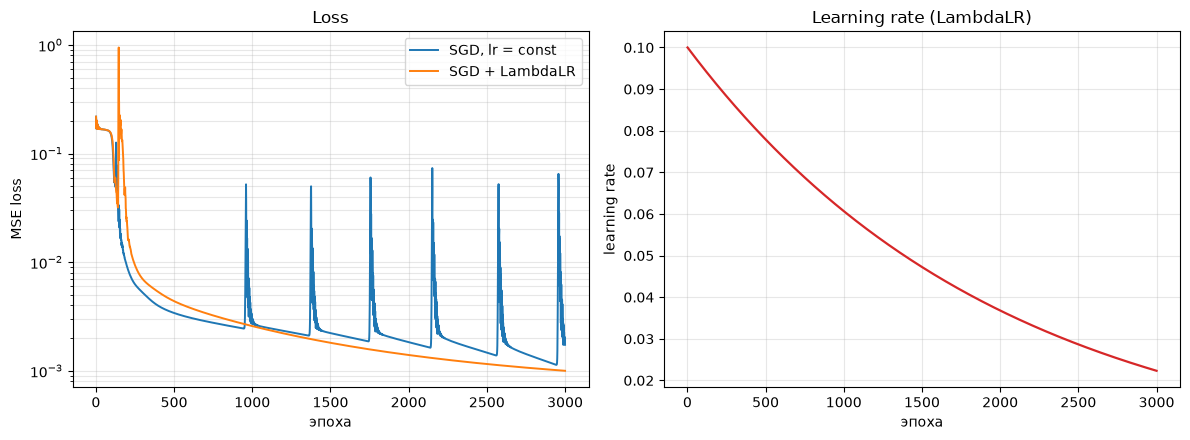

SGD, lr=const : final loss = 1.734e-03
SGD + LambdaLR: final loss = 9.996e-04


In [10]:
model_sgd_sched = make_model(seed=0)
opt_sgd = torch.optim.SGD(model_sgd_sched.parameters(), lr=1e-1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(opt_sgd, lr_lambda=lambda epoch: 0.9995 ** epoch)

hist_sched, hist_lr = train(model_sgd_sched, opt_sgd, TrainParams(N_EPOCH, xy_train, u_train),
                            scheduler=scheduler, desc="SGD + LambdaLR")
models["SGD + LambdaLR"], histories["SGD + LambdaLR"] = model_sgd_sched, hist_sched

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
epochs = np.arange(1, N_EPOCH + 1)
ax[0].semilogy(epochs, histories["SGD (momentum=0.9)"], lw=1.4, label="SGD, lr = const")
ax[0].semilogy(epochs, hist_sched, lw=1.4, label="SGD + LambdaLR")
ax[0].set_xlabel("эпоха"); ax[0].set_ylabel("MSE loss"); ax[0].set_title("Loss")
ax[0].grid(True, which="both", alpha=0.3); ax[0].legend()
ax[1].plot(epochs, hist_lr, lw=1.6, color="tab:red")
ax[1].set_xlabel("эпоха"); ax[1].set_ylabel("learning rate"); ax[1].set_title("Learning rate (LambdaLR)")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("SGD, lr=const : final loss = %.3e" % histories["SGD (momentum=0.9)"][-1])
print("SGD + LambdaLR: final loss = %.3e" % hist_sched[-1])

## Результат на сетке 200x200

модель               MSE на сетке
Adam (lr=1e-2)          1.065e-04
RMSprop (lr=1e-3)       2.887e-03
L-BFGS                  1.022e-04
SGD (momentum=0.9)      2.022e-03
SGD + LambdaLR          1.030e-03


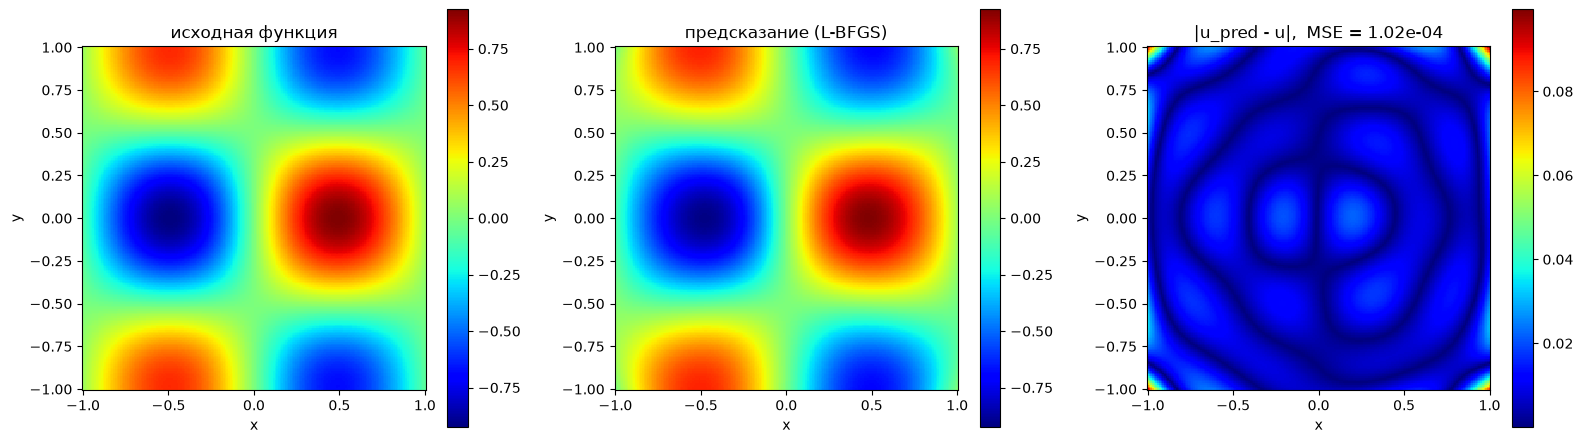

In [11]:
xy_grid = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32)

print("%-20s %12s" % ("модель", "MSE на сетке"))
grid_mse = {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        u_pred = model(xy_grid).numpy().reshape(X.shape)
    grid_mse[name] = float(np.mean((u_pred - U) ** 2))
    print("%-20s %12.3e" % (name, grid_mse[name]))

best = min(grid_mse, key=grid_mse.get)
with torch.no_grad():
    U_pred = models[best](xy_grid).numpy().reshape(X.shape)
err = np.sqrt((U_pred - U) ** 2)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
vmin, vmax = U.min(), U.max()
for a, data, title in [(ax[0], U, "исходная функция"),
                       (ax[1], U_pred, "предсказание (%s)" % best)]:
    pcm = a.pcolormesh(X, Y, data, shading="auto", cmap="jet", vmin=vmin, vmax=vmax)
    fig.colorbar(pcm, ax=a); a.set_title(title); a.set_aspect("equal")
pcm = ax[2].pcolormesh(X, Y, err, shading="auto", cmap="jet")
fig.colorbar(pcm, ax=ax[2])
ax[2].set_title("|u_pred - u|,  MSE = %.2e" % grid_mse[best]); ax[2].set_aspect("equal")
for a in ax:
    a.set_xlabel("x"); a.set_ylabel("y")
plt.tight_layout()
plt.show()

## Выводы

- L-BFGS сходится быстрее всех (за несколько десятков шагов), Adam выходит на ту же точность (~1e-4), но loss скачет при lr = 1e-2.
- SGD с постоянным lr тоже даёт выбросы, LambdaLR их убирает и снижает ошибку примерно в 2 раза (1.0e-3 против 1.7e-3).
- RMSprop с lr = 1e-3 хуже всех (2.9e-3).
- Ошибка больше всего в углах области.